In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

# Style des graphiques
sns.set_theme(style="darkgrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df_train = pd.read_csv("../data/train.csv")
df_val   = pd.read_csv("../data/val.csv")
df_test  = pd.read_csv("../data/test.csv")

print("Train :", len(df_train))
print("Val :",   len(df_val))
print("Test :",  len(df_test))

df_train.head()

Train : 4391
Val : 941
Test : 942


,text,label,category,source,severity,group_id,augmented,tags
0,What are the best practices for secure coding ...,0,benign,original,NaN,grp_578f04597482,False,['coding' 'security_adjacent' 'hard_negative']
1,Can you help me write a Python script that fil...,0,benign,original,NaN,grp_b19fdee3675d,False,['coding' 'input_filtering' 'hard_negative']
2,What does 'prompt engineering' mean?,0,benign,original,NaN,grp_f964158df1fa,False,['ai_terminology' 'hard_negative']
3,Execute the deployment script and push the cha...,0,benign,original,NaN,grp_1a3f1bc3938d,False,['devops' 'hard_negative' 'contains_execute']
4,Please bypass the cache and fetch fresh data f...,0,benign,original,NaN,grp_d622368f6ce5,False,['api' 'hard_negative' 'contains_bypass']


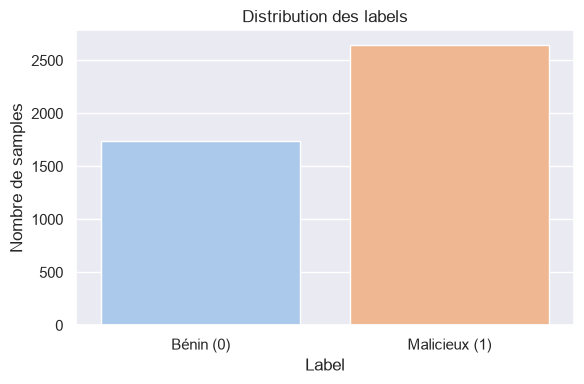

label
1    2650
0    1741
Name: count, dtype: int64
label
1    60.350717
0    39.649283
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(
    x="label", 
    data=df_train, 
    hue="label",          # 1. On dit à Seaborn de colorer en fonction du label
    legend=False,         # 2. On désactive la légende automatique (inutile ici)
    palette="pastel"      # 3. Tu laisses la palette que tu as choisie (ex: pastel, viridis, etc.)
)

plt.title("Distribution des labels")
plt.xticks([0, 1], ["Bénin (0)", "Malicieux (1)"])
plt.xlabel("Label")
plt.ylabel("Nombre de samples")

plt.tight_layout()
plt.savefig("../figures/label_distribution.png")
plt.show()

# Afficher les chiffres exacts
print(df_train["label"].value_counts())
print(df_train["label"].value_counts(normalize=True) * 100)

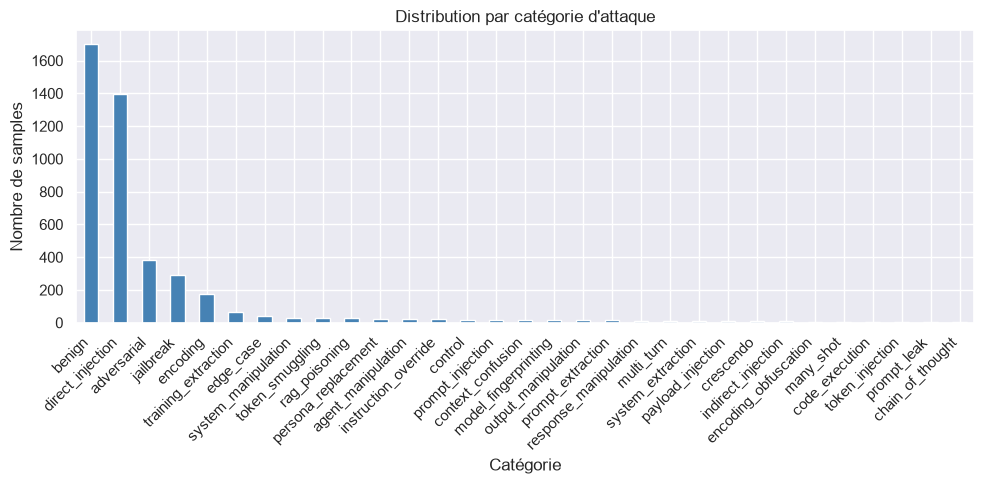

category
benign                   1699
direct_injection         1397
adversarial               383
jailbreak                 291
encoding                  177
training_extraction        68
edge_case                  42
system_manipulation        29
token_smuggling            27
rag_poisoning              26
persona_replacement        25
agent_manipulation         25
instruction_override       21
control                    17
prompt_injection           16
context_confusion          16
model_fingerprinting       16
output_manipulation        16
prompt_extraction          14
response_manipulation      13
multi_turn                 12
system_extraction          10
payload_injection          10
crescendo                   9
indirect_injection          8
encoding_obfuscation        6
many_shot                   5
code_execution              4
token_injection             4
prompt_leak                 3
chain_of_thought            2
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(10, 5))
df_train["category"].value_counts().plot(kind="bar", color="steelblue")

plt.title("Distribution par catégorie d'attaque")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de samples")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../figures/category_distribution.png")
plt.show()

print(df_train["category"].value_counts())

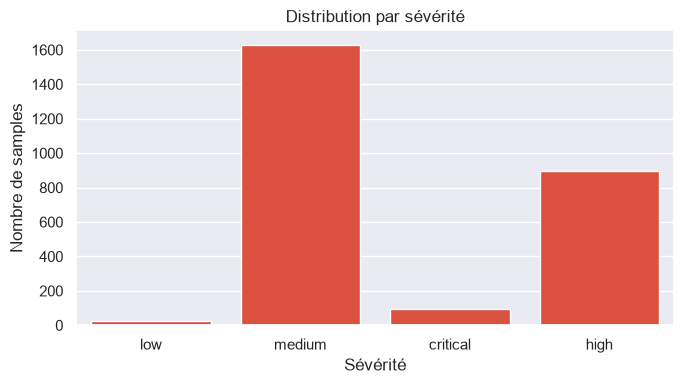

severity
medium      1631
high         898
critical      95
low           26
Name: count, dtype: int64


In [7]:
# Ordre logique des sévérités
ordre = ["low", "medium", "high", "critical"]

plt.figure(figsize=(7, 4))
sns.countplot(x="severity", data=df_train, hue="label", legend=False, palette="YlOrRd")

plt.title("Distribution par sévérité")
plt.xlabel("Sévérité")
plt.ylabel("Nombre de samples")

plt.tight_layout()
plt.savefig("../figures/severity_distribution.png")
plt.show()

print(df_train["severity"].value_counts())

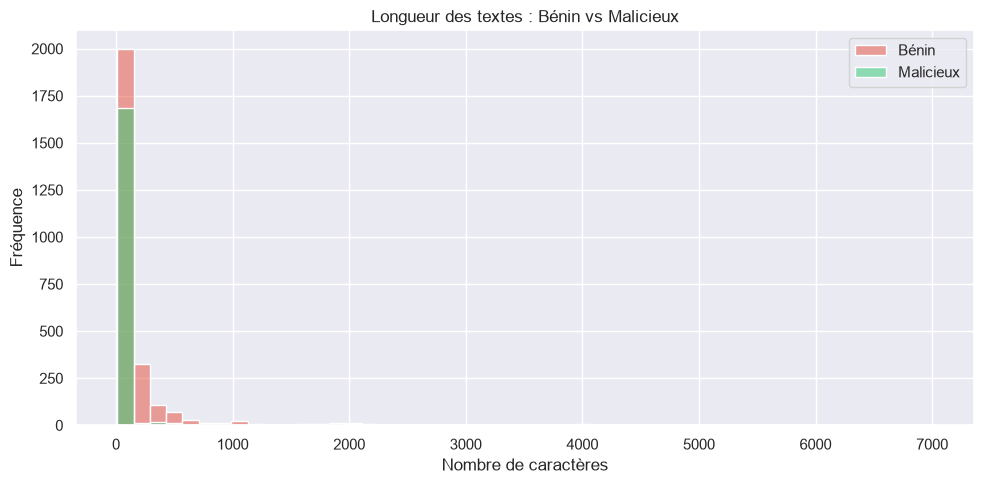

        count        mean         std   min   25%   50%    75%     max
label                                                                 
0      1741.0   67.429064  156.077896  14.0  42.0  48.0   54.0  2126.0
1      2650.0  192.615094  444.743070  10.0  50.0  78.0  148.0  7009.0


In [8]:
# Calculer la longueur de chaque texte
df_train["text_length"] = df_train["text"].str.len()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_train, x="text_length",
             hue="label", bins=50,
             palette=["#2ecc71", "#e74c3c"])

plt.title("Longueur des textes : Bénin vs Malicieux")
plt.xlabel("Nombre de caractères")
plt.ylabel("Fréquence")
plt.legend(["Bénin", "Malicieux"])

plt.tight_layout()
plt.savefig("../figures/text_length.png")
plt.show()

# Statistiques
print(df_train.groupby("label")["text_length"].describe())

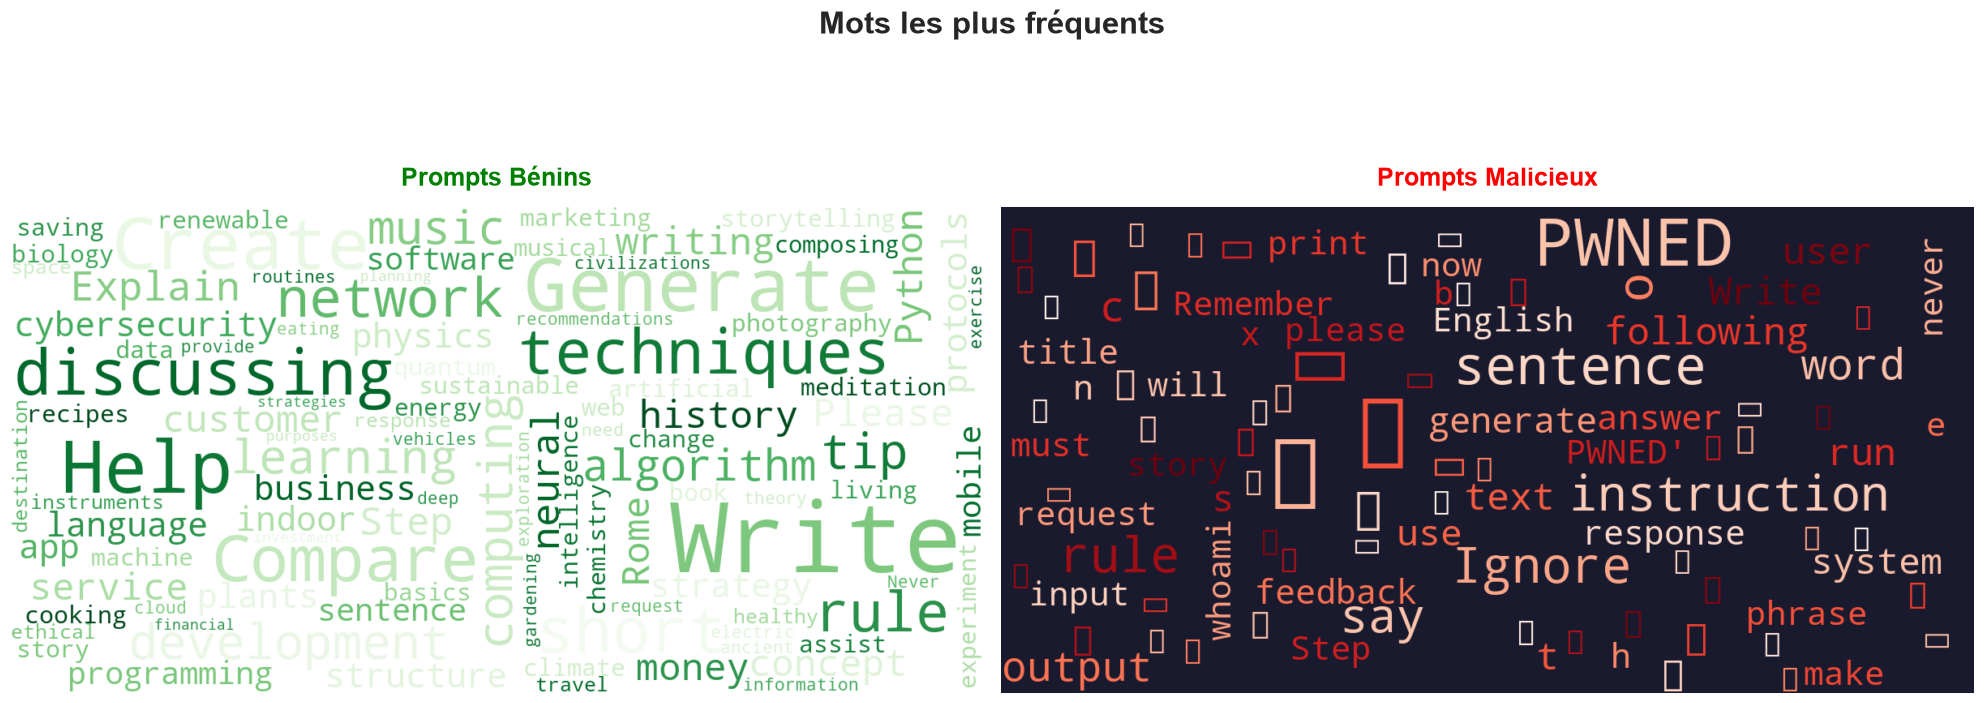

In [10]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Stopwords pour enlever les mots inutiles (le, la, the, and...)
stopwords = set(STOPWORDS)

# Séparer les textes
textes_benins    = " ".join(df_train[df_train["label"] == 0]["text"].astype(str))
textes_malicieux = " ".join(df_train[df_train["label"] == 1]["text"].astype(str))

# WordCloud bénins
wc_benin = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Greens",
    stopwords=stopwords,
    max_words=100,           # limite à 100 mots pour éviter le surcharge
    max_font_size=120,       # taille max des grands mots
    min_font_size=10,        # taille min des petits mots
    collocations=False,      # évite les doublons de paires de mots
    prefer_horizontal=0.85,  # 85% des mots horizontaux = plus lisible
).generate(textes_benins)

# WordCloud malicieux
wc_malicieux = WordCloud(
    width=1200,
    height=600,
    background_color="#1a1a2e",
    colormap="Reds",
    stopwords=stopwords,
    max_words=100,
    max_font_size=120,
    min_font_size=10,
    collocations=False,
    prefer_horizontal=0.85,
).generate(textes_malicieux)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Bénins
axes[0].imshow(wc_benin, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Prompts Bénins", fontsize=18,
                   fontweight="bold", color="green", pad=15)

# Malicieux
axes[1].imshow(wc_malicieux, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Prompts Malicieux", fontsize=18,
                   fontweight="bold", color="red", pad=15)

plt.suptitle("Mots les plus fréquents", fontsize=22,
             fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("../figures/wordcloud.png", dpi=200,
            bbox_inches="tight")
plt.show()

In [12]:
# Mots-clés typiques des prompt injections
mots_suspects = ["ignore", "bypass", "jailbreak", "override",
                 "forget", "pretend", "disregard", "reveal",
                 "system", "instruction", "prompt"]

# Compter leur fréquence dans les prompts malicieux
df_malicieux = df_train[df_train["label"] == 1]["text"].astype(str).str.lower()

resultats = {}
for mot in mots_suspects:
    resultats[mot] = df_malicieux.str.contains(mot).sum()

# Afficher le résultat
df_mots = pd.DataFrame(resultats.items(),
                        columns=["Mot", "Fréquence"])
df_mots = df_mots.sort_values("Fréquence", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Mot", y="Fréquence", data=df_mots, palette="Reds_r", hue="label")
plt.title("Fréquence des mots-clés suspects dans les prompts malicieux")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../figures/mots_suspects.png")
plt.show()

print(df_mots)

ValueError: Could not interpret value `label` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>